In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow import keras
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/Colab Notebooks/breast_cancer.csv'
df = pd.read_csv(path)

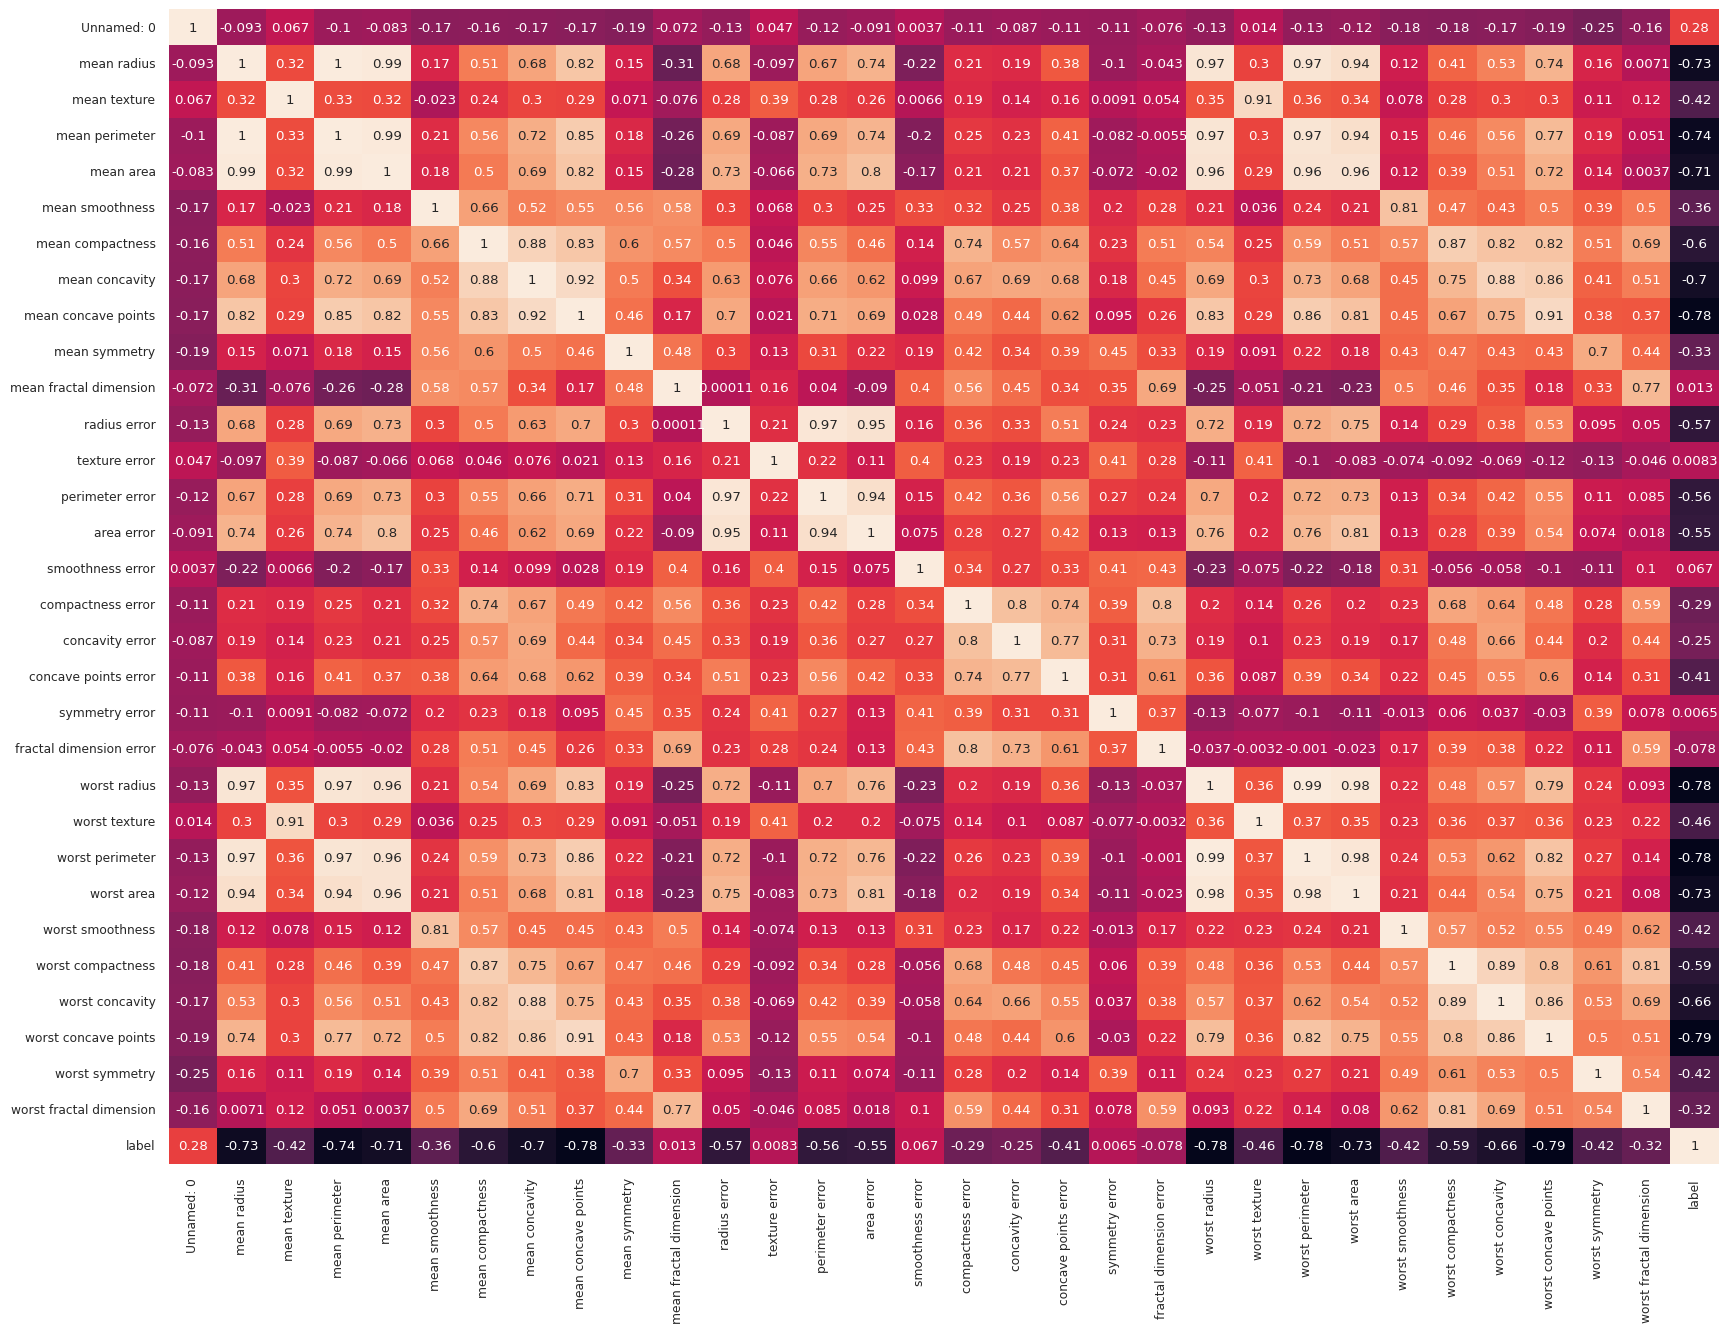

In [5]:
df_corr=df.corr()

#히트맵
plt.figure(figsize=(20, 15))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X=df.drop('worst compactness',axis=1)
X.head()

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4504,0.2430,0.3613,0.08758,0
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.6869,0.2575,0.6638,0.17300,0
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.4000,0.1625,0.2364,0.07678,0


In [8]:
y = df['worst compactness']
Y = y.values

In [9]:
X = pd.get_dummies(df.drop('worst compactness', axis=1), columns=['label'], dtype=int)
X = X.values
print(X.shape)

(569, 32)


In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# 1. fit_transform: 훈련 데이터의 평균과 표준편차를 '계산(fit)'하고 바로 '변환(transform)'합니다. 모든 데이터를 평균을 0 표준편차는 1로 변신
X_train = scaler.fit_transform(X_train)

# 2. transform: 중요! 훈련 데이터에서 구한 '그 기준 그대로' 테스트 데이터도 변환합니다.
# (테스트 데이터로 새로 계산하면 안 돼요. 시험 문제는 공부한 기준대로 풀어야 하니까요!)
X_test = scaler.transform(X_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape,

((455, 32), (455,), (114, 32), (114,))

In [11]:
#Defining the model

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam


model = Sequential()

#입력 컬럼이 32개임
model.add(Dense(8,input_shape=(32,),activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(1))
#결과가 1개이므로 마지막은 1로 끝남

model.compile(optimizer = 'rmsprop', loss = 'mse', metrics = ['mse'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,495 (5.84 KB)

 Trainable params: 1,495 (5.84 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
N_EPOCHS = 10

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.4016 - mse: 0.4016 - val_loss: 0.1545 - val_mse: 0.1545
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0859 - mse: 0.0859 - val_loss: 0.0745 - val_mse: 0.0745
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0386 - mse: 0.0386 - val_loss: 0.0479 - val_mse: 0.0479
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0241 - mse: 0.0241 - val_loss: 0.0350 - val_mse: 0.0350
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0181 - mse: 0.0181 - val_loss: 0.0294 - val_mse: 0.0294
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0155 - mse: 0.0155 - val_loss: 0.0249 - val_mse: 0.0249
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0135 - mse: 0.0135 - val_loss: 0.0210 - val_mse: 0.0210
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0122 - mse: 0.0122 - val_loss: 0.0217 - val_mse: 0.0217
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0114 -

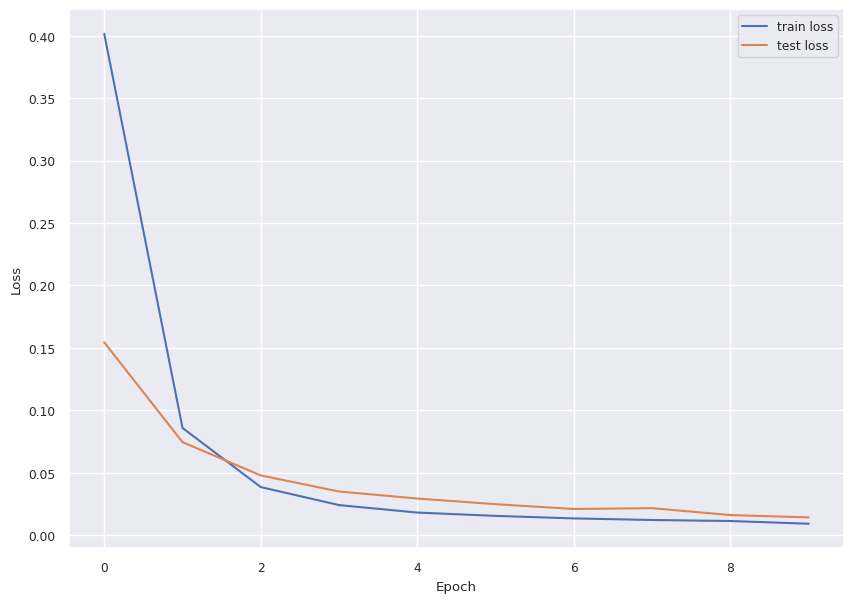

In [13]:
# loss 체크
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [14]:
model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0143 - mse: 0.0143


[0.014284852892160416, 0.014284852892160416]